In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import os

# ==== SETTINGS ====
csv_path = "sensor_data.csv"     # path to your CSV
fs = 10                  # sampling frequency in Hz (CHANGE THIS)
output_folder = "spectrograms"

# ==================

os.makedirs(output_folder, exist_ok=True)

# Load CSV
df = pd.read_csv(csv_path)

# Columns to process
columns = ["wx", "wy", "wz", "ax", "ay", "az"]

for col in columns:
    if col not in df.columns:
        print(f"Column {col} not found. Skipping.")
        continue

    signal = df[col].values

    # Compute spectrogram
    f, t, Sxx = spectrogram(signal, fs=fs)

    # Plot
    plt.figure(figsize=(8,5))
    plt.pcolormesh(t, f, Sxx, shading='gouraud')
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (sec)")
    plt.title(f"Spectrogram - {col}")
    plt.colorbar(label="Intensity")

    # Save image
    save_path = os.path.join(output_folder, f"{col}_spectrogram.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"Saved {save_path}")


Saved spectrograms\wx_spectrogram.png
Saved spectrograms\wy_spectrogram.png
Saved spectrograms\wz_spectrogram.png
Saved spectrograms\ax_spectrogram.png
Saved spectrograms\ay_spectrogram.png
Saved spectrograms\az_spectrogram.png


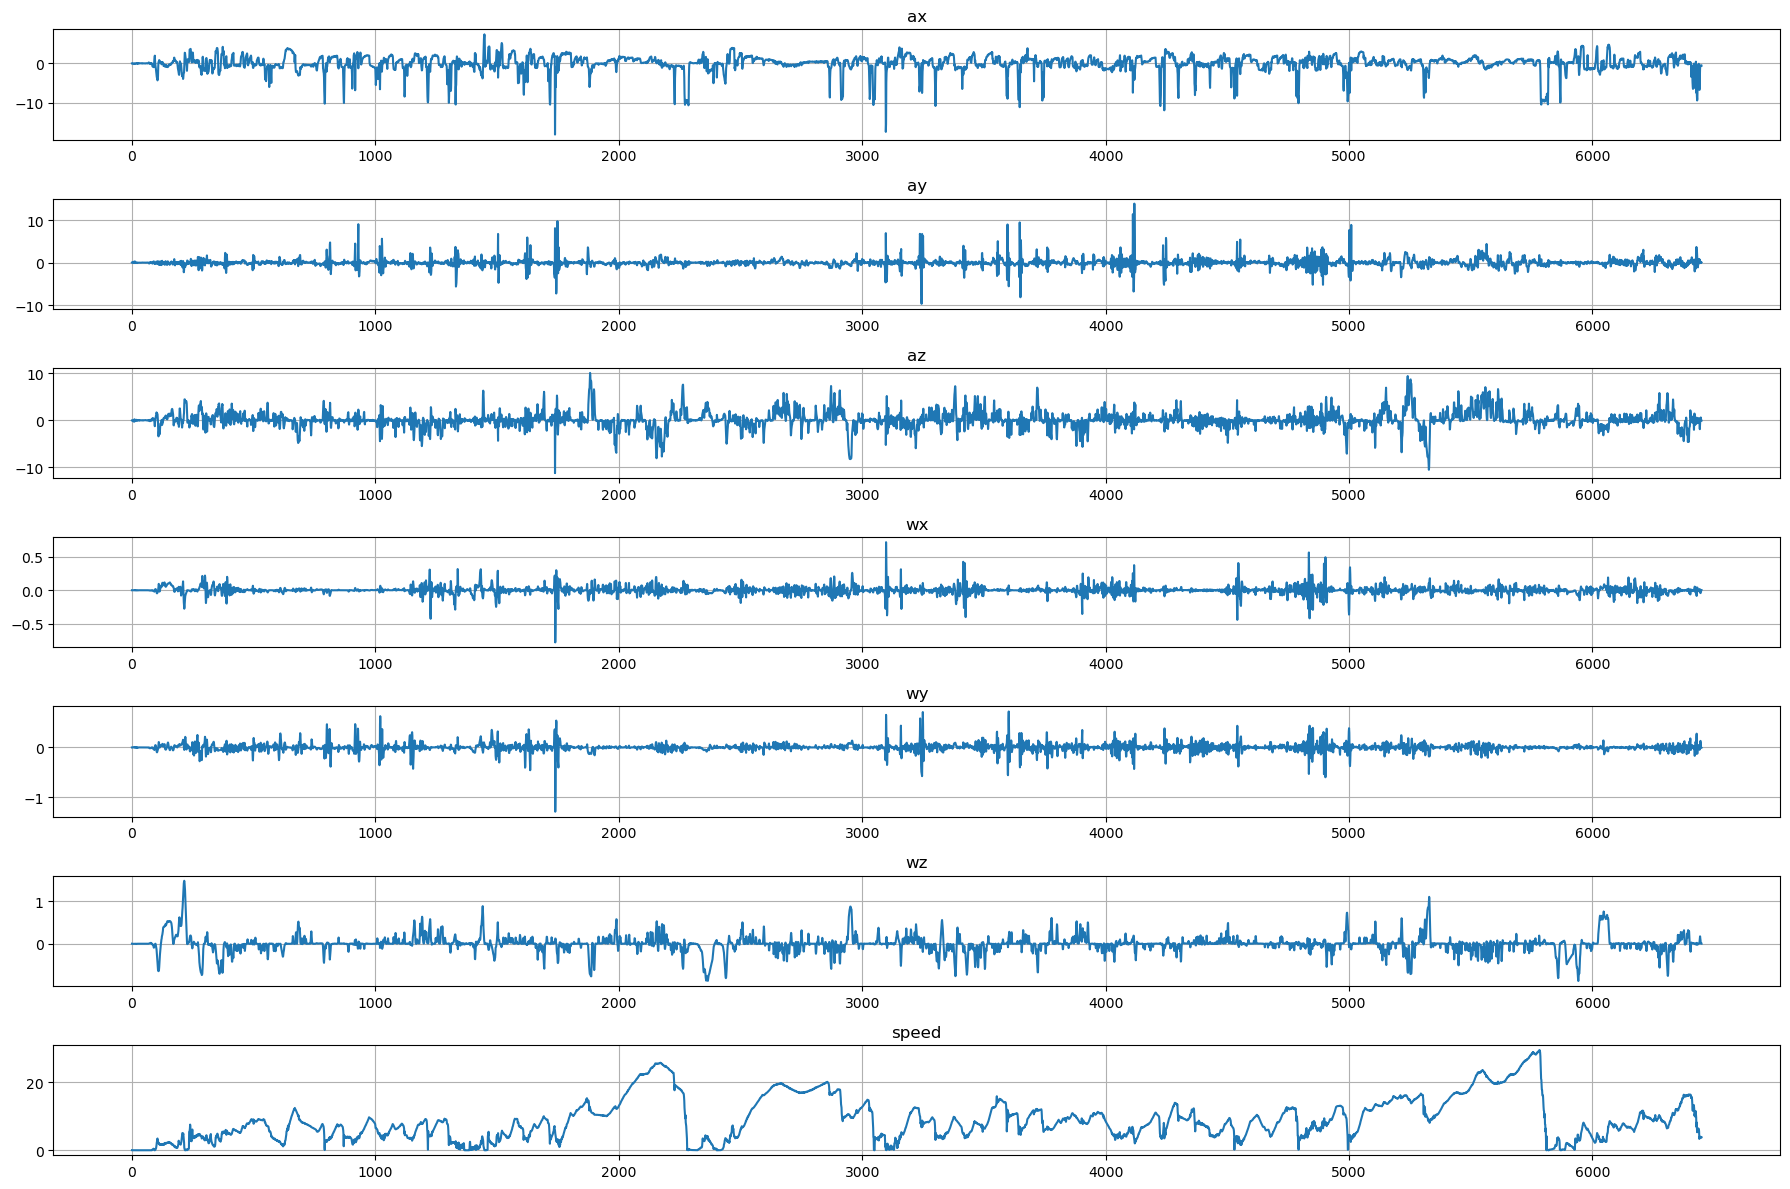

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === CHANGE ONLY THIS ===
name = "sensor_data.csv"
# ========================

base_path = r""
file_path = os.path.join(base_path, name)

df = pd.read_csv(file_path)

features = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed']
x_full = np.arange(len(df))

plt.figure(figsize=(18, 12))

for idx, feature in enumerate(features, 1):
    plt.subplot(len(features), 1, idx)
    plt.plot(x_full, df[feature])
    plt.title(feature)
    plt.grid(True)

plt.tight_layout()

# --- create plots folder if not exists ---
plots_folder = "plots"
os.makedirs(plots_folder, exist_ok=True)

# --- save plot with same name as file ---
file_name_without_ext, ext = os.path.splitext(name)
save_path = os.path.join(plots_folder, file_name_without_ext + ".png")

plt.savefig(save_path)
plt.show()
